In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
    
import os, sys, glob
import json
import re
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append('/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/')

from config import *
import dataset_utils as utils
import analysis_utils as analysis
import plotting_utils as plotting

## Set directories

In [ ]:
EXPERIMENT_NAME = 'next-word-prediction'
EXPERIMENT_VERSION = 'final-multimodal-01'

# set the directories we need
results_dir = os.path.join(BASE_DIR, 'experiments',  EXPERIMENT_NAME, 'results', EXPERIMENT_VERSION)
cleaned_results_dir = os.path.join(BASE_DIR, 'experiments',  EXPERIMENT_NAME, 'cleaned-results', EXPERIMENT_VERSION)

## Load files for each

In [ ]:
def get_cleaning_stats(src_dir, cleaned_dir, modality):

    src_dir = Path(os.path.join(src_dir, modality))
    cleaned_dir = Path(os.path.join(cleaned_dir, modality))

    # Grab the subject directories
    src_sub_dirs = sorted(src_dir.glob('*sub*'))
    cleaned_sub_dirs = sorted(cleaned_dir.glob('*sub*'))

    all_corrections = {
        'spell-corrected': [],
        'shortened': [],
        'n_words': [],
    }

    # Go through each subject
    for src_sub_dir, cleaned_sub_dir in zip(src_sub_dirs, cleaned_sub_dirs):

        # Check that the subject directories match
        assert (src_sub_dir.name == cleaned_sub_dir.name), 'Subject directories do not match'

        # Responses being trimmed by one for video is now accounted for in load_participant_results
        _, _, _, src_responses = analysis.load_participant_results(src_sub_dir.as_posix(), src_sub_dir.name)
        _, _, _, cleaned_responses = analysis.load_participant_results(cleaned_sub_dir.as_posix(), cleaned_sub_dir.name)

        if modality == 'video':
            src_responses = src_responses.iloc[:-1, :]
        
        src_responses['response'] = src_responses['response'].apply(lambda x: str(x))
        cleaned_responses['response'] = cleaned_responses['response'].apply(lambda x: str(x))

        # Find percentage mismatched responses
        change_mask = src_responses['response'] != cleaned_responses['response']

        # Grab the changed responses
        changed_responses = src_responses.loc[change_mask, :]

        # Find whether it was one-word or multiple words
        changed_lengths = changed_responses['response'].str.split().apply(len)

        # Divide into spell-corrected vs. shortened
        spell_corrected = changed_lengths == 1
        shortened = changed_lengths > 1

        if shortened:
            return changed_responses

        # Track percent spell checked / shortened
        total_spell_corrected = sum(spell_corrected)
        total_shortened = sum(shortened)

        # Add into the tracking
        all_corrections['spell-corrected'].append(total_spell_corrected)
        all_corrections['shortened'].append(total_shortened)
        all_corrections['n_words'].append(len(change_mask))

    return all_corrections

Go through each task and modality

In [44]:
from pathlib import Path

modalities = ['video', 'audio', 'text'] # video',
task_list = ['black', 'wheretheressmoke', 'howtodraw']

df_modalities = []

for task in task_list:

    # set the directories we need
    base_dir = Path(BASE_DIR)

    if task == 'black':
        EXPERIMENT_VERSION = 'pilot-multimodal-01'
    else:
        EXPERIMENT_VERSION = 'final-multimodal-01'

    results_dir = base_dir / f"experiments/{EXPERIMENT_NAME}/results/{EXPERIMENT_VERSION}"
    cleaned_results_dir = base_dir / f"experiments/{EXPERIMENT_NAME}/cleaned-results/{EXPERIMENT_VERSION}"
        
    for modality in modalities:

        print (f'Processing {task} {modality}')

        src_dir = Path(os.path.join(results_dir, task))
        cleaned_dir = Path(os.path.join(cleaned_results_dir, task))

        modality_corrections = get_cleaning_stats(src_dir, cleaned_dir, modality)

        df_modality = pd.DataFrame.from_dict(modality_corrections)
        df_modality['modality'] = modality
        df_modality['task'] = task

        df_modalities.append(df_modality)

df_modalities = pd.concat(df_modalities).reset_index(drop=True)

Processing black video
Processing black audio
Processing black text
Processing wheretheressmoke video
Processing wheretheressmoke audio
Processing wheretheressmoke text
Processing howtodraw video
Processing howtodraw audio
Processing howtodraw text


In [ ]:
df_summed = df_modalities.groupby('modality').agg('sum')
percents_changed = df_summed.loc[:, ['spell-corrected', 'shortened']] / df_summed.loc[:, 'n_words'].values[:, None]

In [55]:
df_summed.loc[:, 'n_words'].values.shape

(3,)

In [ ]:
from scipy.stats import ttest_ind





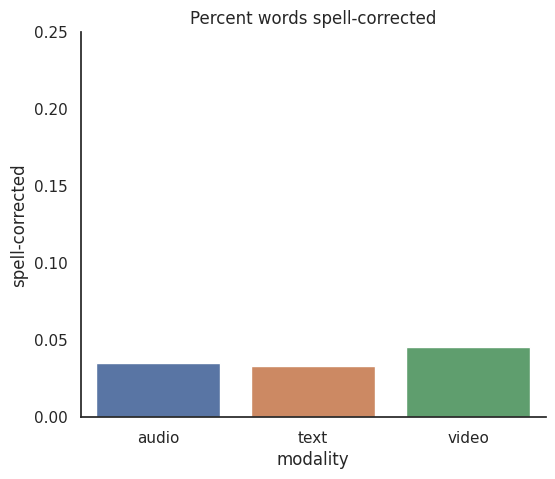

In [68]:
import seaborn as sns

item = 'spell-corrected'

df_summed = df_modalities.groupby('modality').agg('sum')
percents_changed = df_summed.loc[:, ['spell-corrected', 'shortened']] / df_summed.loc[:, 'n_words'].values[:, None]

# df_audio, df_text = [df for mod, df in df_modalities.groupby('modality')]

# ttest_ind(df_audio[item], df_text[item])

sns.barplot(data=percents_changed, x='modality', y=item, hue='modality', legend=False)
plt.title(f'Percent words {item}')
plt.ylim([0, 0.25])

sns.despine()

In [35]:
window_size = 25

results_dir = os.path.join(BASE_DIR, 'derivatives/results/behavioral/')

out_fn = os.path.join(results_dir, f'all-task_group-analyzed-behavior_window-size-{str(window_size).zfill(5)}_human-model-lemmatized.csv')
df_results = pd.read_csv(out_fn)

# df_results.to_csv(out_fn, index=False)

df_results.head().columns

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /dartfs/rc/lab/F/FinnLab/tommy/models/token
Login successful


Index(['modality', 'word_index', 'top_pred', 'ground_truth', 'accuracy',
       'fasttext_top_word_accuracy', 'top_prob', 'predictability', 'entropy',
       'entropy_group', 'accuracy_group', 'prominence', 'boundary',
       'prominence_mean_words3', 'prominence_mean_words5',
       'prominence_mean_words7', 'prominence_mean_words9',
       'boundary_mean_words3', 'boundary_mean_words5', 'boundary_mean_words7',
       'boundary_mean_words9', 'POS', 'wrong_resp_n_correct',
       'wrong_resp_n_incorrect', 'wrong_resp_accuracy', 'barnard_stat',
       'barnard_pvalue', 'filter_for_leakage', 'task'],
      dtype='object')

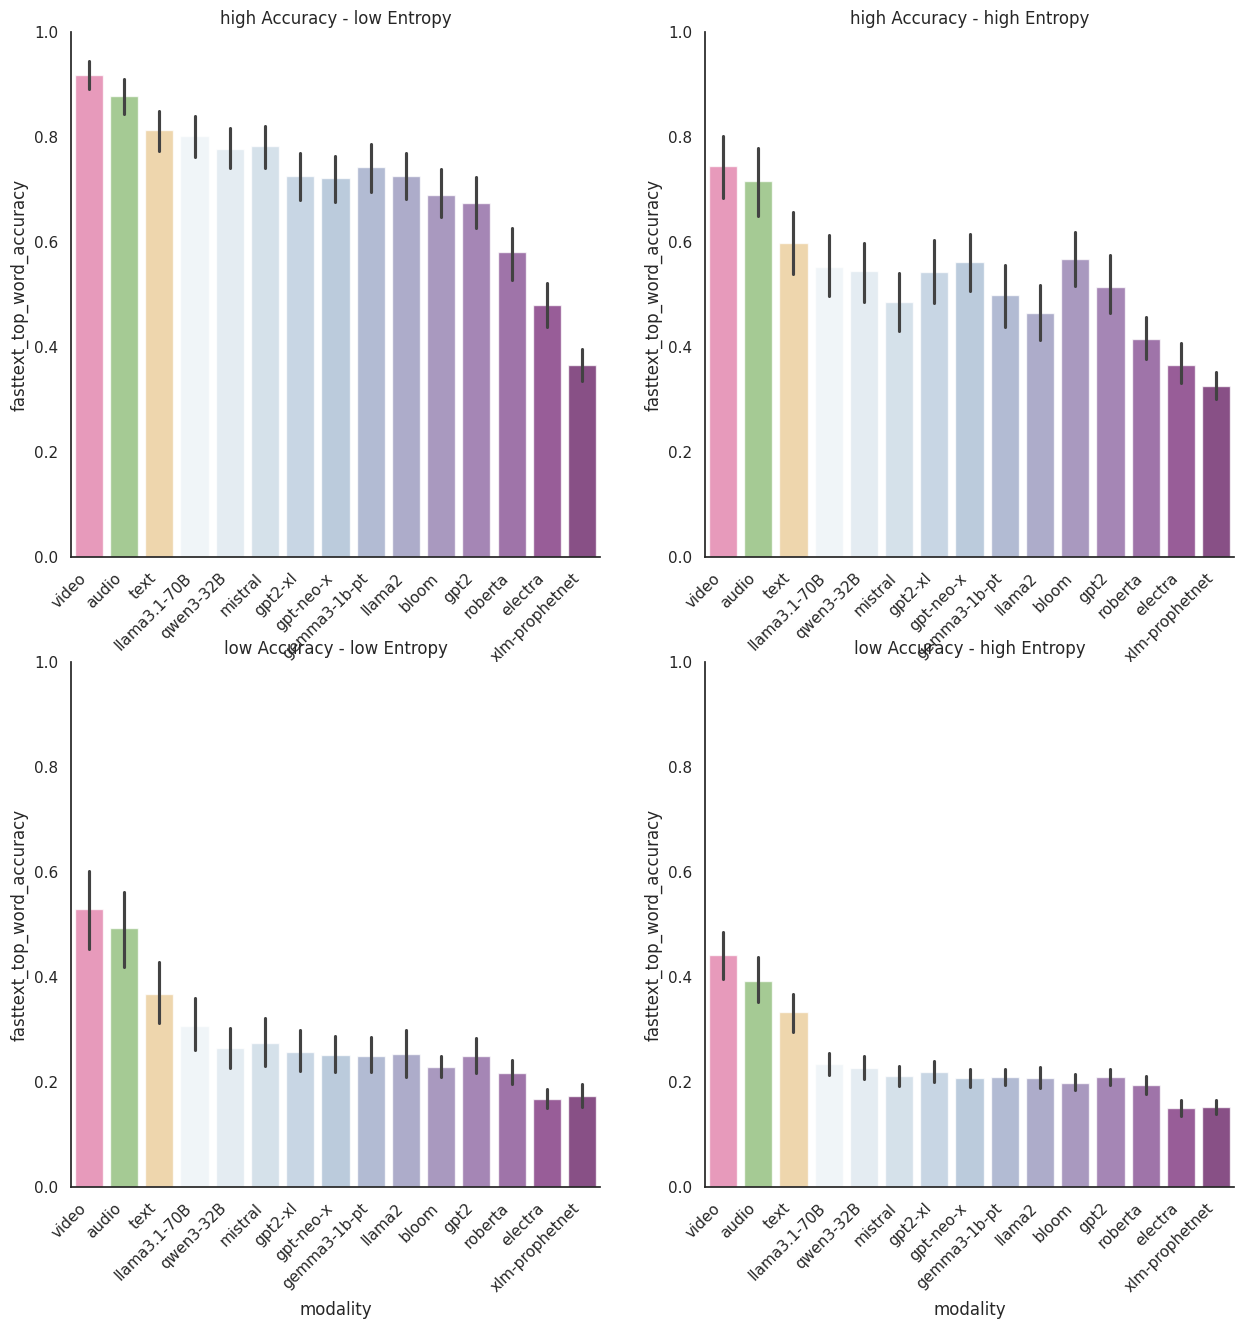

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(15, 15))

axes = axes.flatten()

groups = [
    'high-low',
    'high-high',
    'low-low',
    'low-high',
]

modalities = ['video', 'audio', 'text']

# use the accuracy within these results to get the order to plot the models
ordered_accuracy = plotting.get_ordered_accuracy(df_results)
models_order = [item for item in ordered_accuracy if item not in modalities]
human_models_order = modalities + models_order

cmap = plotting.create_colormap(dtype='multimodal', continuous=False, N_MODELS=len(models_order))

accuracy_type = 'fasttext_top_word_accuracy'

for ax, group in zip(axes, groups):

    accuracy_group, entropy_group = group.split('-')

    df_index = df_results[
        (df_results['accuracy_group'] == accuracy_group) & 
        (df_results['entropy_group'] == entropy_group)
    ]

    ax = plotting.plot_bar_results(
        df_index, 
        x='modality',
        y=accuracy_type, 
        hue=None, 
        order=human_models_order, 
        cmap=cmap, 
        # figsize=FIGSIZE, 
        add_points=False, 
        ax=ax)

    ax.set_title(f'{accuracy_group} Accuracy - {entropy_group} Entropy')
    ax.set_ylim([0, 1.0])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [13]:
modalities = ['video', 'audio', 'text']

# use the accuracy within these results to get the order to plot the models
ordered_accuracy = plotting.get_ordered_accuracy(df_results)

# always put humans first (audio, text) then CLM models, then MLM models
models_order = [item for item in ordered_accuracy if item not in modalities]

human_models_order = modalities + models_order

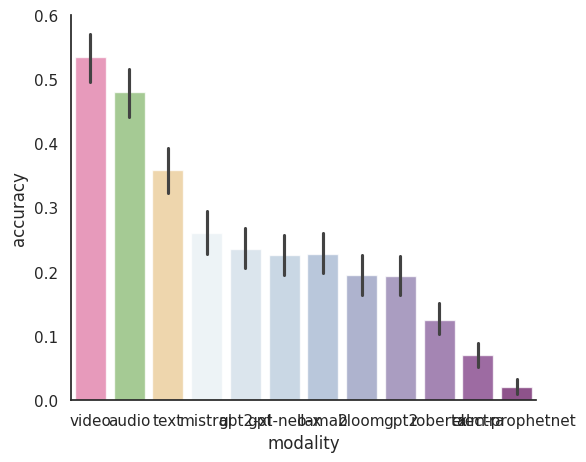

In [7]:
df_results.columns

Index(['modality', 'word_index', 'top_pred', 'ground_truth', 'accuracy',
       'fasttext_top_word_accuracy', 'top_prob', 'predictability', 'entropy',
       'entropy_group', 'accuracy_group', 'prominence', 'boundary',
       'prominence_mean_words3', 'prominence_mean_words5',
       'prominence_mean_words7', 'prominence_mean_words9',
       'boundary_mean_words3', 'boundary_mean_words5', 'boundary_mean_words7',
       'boundary_mean_words9', 'POS', 'wrong_resp_n_correct',
       'wrong_resp_n_incorrect', 'wrong_resp_accuracy', 'barnard_stat',
       'barnard_pvalue', 'filter_for_leakage', 'task'],
      dtype='object')